# Pipeline de Séries Temporais: SARIMA Vs. Base Models

## Etapa 1: Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

## Etapa 2: Arquivos

In [2]:
ARQUIVOS = [
    {
        'nome':    'Mean Pressure',
        'path':    'serie_atv_2.csv',
        'coluna':  'meanpressure',
        'sazonalidade': 1
    }
]

## Etapa 3: Funções

In [3]:
def carregar_serie(arquivo):
    df = pd.read_csv(arquivo['path'])
    serie = df[arquivo['coluna']].dropna().reset_index(drop=True)
    return serie

In [4]:
def plotar_serie(serie, nome):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(serie.values, color='#2563eb', linewidth=1.2)
    ax.set_title(f'{nome}', fontweight='bold')
    ax.set_xlabel('Tempo')
    ax.set_ylabel('Valor')
    plt.tight_layout()
    plt.show()

In [5]:
def plotar_acf_pacf(serie, nome, n_lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(serie,  lags=n_lags, ax=axes[0], title=f'ACF: {nome}')
    plot_pacf(serie, lags=n_lags, ax=axes[1], title=f'PACF: {nome}')
    for ax in axes:
        ax.set_xlabel('Lag')
    plt.tight_layout()
    plt.show()

In [6]:
def teste_adf(serie, alpha=0.05):
    resultado_adf = adfuller(serie)
    estatistica_adf = resultado_adf[0]
    p_valor = resultado_adf[1]
    estacionaria = p_valor <= alpha
    print(f'ADF: resultado={estatistica_adf:.4f}  p={p_valor:.4f}'
          f' = {"Estacionária ✅" if estacionaria else "Não Estacionária ❌"}')
    return estacionaria

In [7]:
def teste_kpss(serie, alpha=0.05):
    resultado_kpss = kpss(serie)
    estatistica_kpss = resultado_kpss[0]
    p_valor = resultado_kpss[1]
    estacionaria = p_valor > alpha
    print(f'KPSS: resultado={estatistica_kpss:.4f}  p={p_valor:.4f}'
          f' = {"Estacionária ✅" if estacionaria else "Não Estacionária ❌"}')
    return estacionaria

In [8]:
def avaliar_estacionariedade(serie):
    adf = teste_adf(serie)
    kpss = teste_kpss(serie)
    if adf and kpss:
        print('Conclusão: A série é estacionária ✅')
        return True
    elif not adf and not kpss:
        print('Conclusão: A série é não estacionária ❌')
    elif adf and not kpss:
        print('Conclusão: Conflito ADF estacionário / KPSS não estacionário - tratada como não estacionária ⚠️')
    else:
        print('Conclusão: Conflito ADF não estacionário / KPSS estacionário - tratada como não estacionária ⚠️')
    return False

In [9]:
def formatar(texto, nivel=2):
    prefixos = {1: '\n' + '═'*65, 2: '─'*55, 3: '·'*45}
    sep = prefixos.get(nivel, '')
    if nivel == 1:
        print(f'{sep}\n  {texto}\n{sep}')
    else:
        print(f'\n{sep}\n  {texto}\n{sep}')

In [10]:
def dividir_serie(serie, proporcao_teste=0.2):
    n_teste = max(1, int(len(serie) * proporcao_teste))
    treino  = serie.iloc[:-n_teste].reset_index(drop=True)
    teste   = serie.iloc[-n_teste:].reset_index(drop=True)
    print(f'Total: {len(serie)} obs  |  Treino: {len(treino)}  |  Teste: {len(teste)}')
    return treino, teste

In [11]:
def _rolling_prev(treino, teste, fn):
    serie = pd.concat([treino, teste], ignore_index=True)
    return fn(serie).shift(1).iloc[len(treino):].values

In [12]:
def modelo_media_historica(treino, teste):
    return np.full(len(teste), treino.mean())

In [13]:
def modelo_media_acumulada(treino, teste):
    return _rolling_prev(treino, teste, lambda s: s.expanding().mean())

In [14]:
def modelo_sma(treino, teste, janela):
    return _rolling_prev(treino, teste, lambda s: s.rolling(window=int(janela)).mean())

In [15]:
def modelo_ema(treino, teste, alpha):
    return _rolling_prev(treino, teste, lambda s: s.ewm(alpha=float(alpha), adjust=False).mean())

In [16]:
def modelo_seasonal_naive(treino, teste, s):
    return _rolling_prev(treino, teste, lambda s_: s_.shift(int(s)))

In [17]:
def modelo_naive_drift(treino, teste, k):
    serie = pd.concat([treino, teste], ignore_index=True)
    drift = (serie.shift(1) - serie.shift(1 + int(k))) / int(k)
    return (serie.shift(1) + drift).iloc[len(treino):].values

In [18]:
def _otimizar_param(treino, modelo_fn, params):
    n_val    = max(2, int(len(treino) * 0.2))
    tr_int   = treino.iloc[:-n_val].reset_index(drop=True)
    val_int  = treino.iloc[-n_val:].reset_index(drop=True)

    melhor_param, melhor_mae = params[0], np.inf
    for p in params:
        try:
            prev     = modelo_fn(tr_int, val_int, p)
            mascara  = ~np.isnan(prev)
            if mascara.sum() == 0:
                continue
            mae = np.mean(np.abs(prev[mascara] - val_int.values[mascara]))
            if mae < melhor_mae:
                melhor_mae   = mae
                melhor_param = p
        except Exception:
            continue
    return melhor_param

In [19]:
def aplicar_base_models(treino, teste, sazonalidade):
    max_k   = max(2, min(len(treino) // 4, 15))
    janelas = list(range(1, max_k + 1))
    alphas  = np.round(np.arange(0.1, 1.0, 0.1), 2).tolist()

    k_sma   = _otimizar_param(treino, modelo_sma,         janelas)
    alpha   = _otimizar_param(treino, modelo_ema,         alphas)
    k_drift = _otimizar_param(treino, modelo_naive_drift, janelas)

    print(f'  Hiperparâmetros selecionados (MAE no treino):')
    print(f'    SMA            → janela = {k_sma}')
    print(f'    EMA            → alpha  = {alpha}')
    print(f'    Naive c/ Drift → k      = {k_drift}')
    print(f'    Seasonal Naive → s      = {sazonalidade}')

    previsoes = {
        'Média Histórica':                    modelo_media_historica(treino, teste),
        'Média Acumulada':                    modelo_media_acumulada(treino, teste),
        f'SMA (k={k_sma})':                   modelo_sma(treino, teste, k_sma),
        f'EMA (α={alpha})':                   modelo_ema(treino, teste, alpha),
        f'Seasonal Naive (s={sazonalidade})': modelo_seasonal_naive(treino, teste, sazonalidade),
        f'Naive c/ Drift (k={k_drift})':      modelo_naive_drift(treino, teste, k_drift),
    }
    return previsoes

In [20]:
def plotar_base_models(treino, teste, previsoes, nome):
    serie_completa = pd.concat([treino, teste], ignore_index=True)
    n_treino = len(treino)
    x_teste  = np.arange(n_treino, n_treino + len(teste))

    cores   = ['#2563eb', '#16a34a', '#d97706', '#dc2626',
               '#7c3aed', '#0891b2']
    estilos = ['--', '-.', ':', '--', '-.', ':']

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(serie_completa.values, color='#1e293b', linewidth=1.4,
            label='Série Original')
    ax.axvline(x=n_treino - 1, color='#94a3b8', linestyle='--',
               linewidth=1, label='Início do Teste')

    for (nome_modelo, prev), cor, estilo in zip(previsoes.items(), cores, estilos):
        mascara = ~np.isnan(prev)
        x_plot  = x_teste[mascara]
        y_plot  = prev[mascara]
        ax.plot(x_plot, y_plot, linestyle=estilo, color=cor,
                linewidth=1.6, label=nome_modelo)

    ax.set_title(f'Base Models — {nome}', fontweight='bold')
    ax.set_xlabel('Tempo')
    ax.set_ylabel('Valor')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

In [21]:
def treinar_sarima():
    raise NotImplementedError("Implementar treinar_sarima()")

In [22]:
def rolling_forecast():
    raise NotImplementedError("Implementar rolling_forecast()")

In [23]:
def comparar_modelos():
    raise NotImplementedError("Implementar comparar_modelos()")

In [24]:
def calcular_mae():
    raise NotImplementedError("Implementar calcular_mae()")

## Etapa 4: Pipeline

In [25]:
def pipeline_sarima(arquivo, proporcao_teste=0.2):
    nome         = arquivo['nome']
    sazonalidade = arquivo['sazonalidade']

    formatar(f'PIPELINE SARIMA: {nome}', 1)

    formatar('Carregando e visualizando a série...')
    serie = carregar_serie(arquivo)
    plotar_serie(serie, nome)
    plotar_acf_pacf(serie, nome)

    formatar('Dividindo em treino e teste...')
    treino, teste = dividir_serie(serie, proporcao_teste)

    formatar('Avaliando estacionariedade do treino...')
    estacionaria = avaliar_estacionariedade(treino)

    formatar('Treinando Base Models...')
    previsoes_base = aplicar_base_models(treino, teste, sazonalidade)
    plotar_base_models(treino, teste, previsoes_base, nome)

    formatar('Treinando modelo SARIMA...')
    modelo_sarima = treinar_sarima()

    formatar('Realizando Rolling Forecast...')
    previsoes_sarima = rolling_forecast()

    formatar('Comparando SARIMA vs Base Models...')
    comparar_modelos()

    formatar('Calculando MAE e testes...')
    resultados = calcular_mae()

    return resultados

## Etapa 5: Execução


═════════════════════════════════════════════════════════════════
  PIPELINE SARIMA: Mean Pressure

═════════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Carregando e visualizando a série...
───────────────────────────────────────────────────────


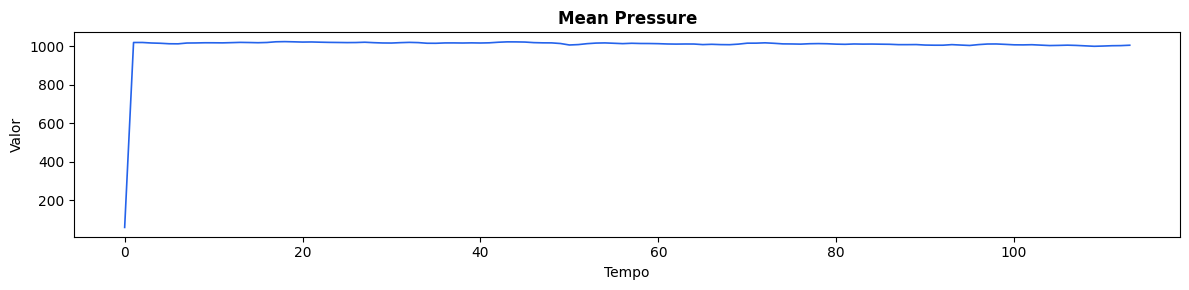

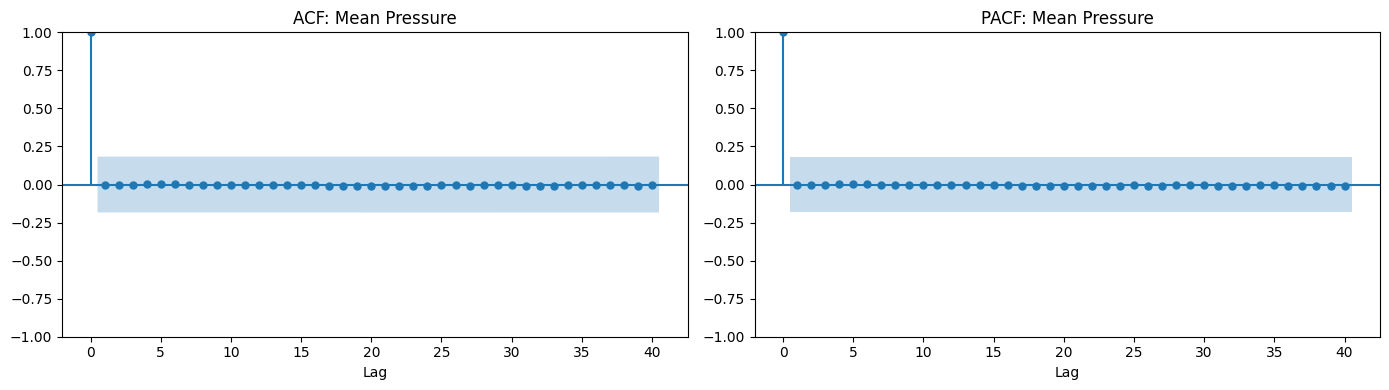


───────────────────────────────────────────────────────
  Dividindo em treino e teste...
───────────────────────────────────────────────────────
Total: 114 obs  |  Treino: 92  |  Teste: 22

───────────────────────────────────────────────────────
  Avaliando estacionariedade do treino...
───────────────────────────────────────────────────────
ADF: resultado=-2.2820  p=0.1779 = Não Estacionária ❌
KPSS: resultado=0.2631  p=0.1000 = Estacionária ✅
Conclusão: Conflito ADF não estacionário / KPSS estacionário - tratada como não estacionária ⚠️

───────────────────────────────────────────────────────
  Treinando Base Models...
───────────────────────────────────────────────────────
  Hiperparâmetros selecionados (MAE no treino):
    SMA            → janela = 1
    EMA            → alpha  = 0.9
    Naive c/ Drift → k      = 7
    Seasonal Naive → s      = 1


C:\Users\giovannapelati-ieg\AppData\Local\Temp\ipykernel_16068\1750357182.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado_kpss = kpss(serie)


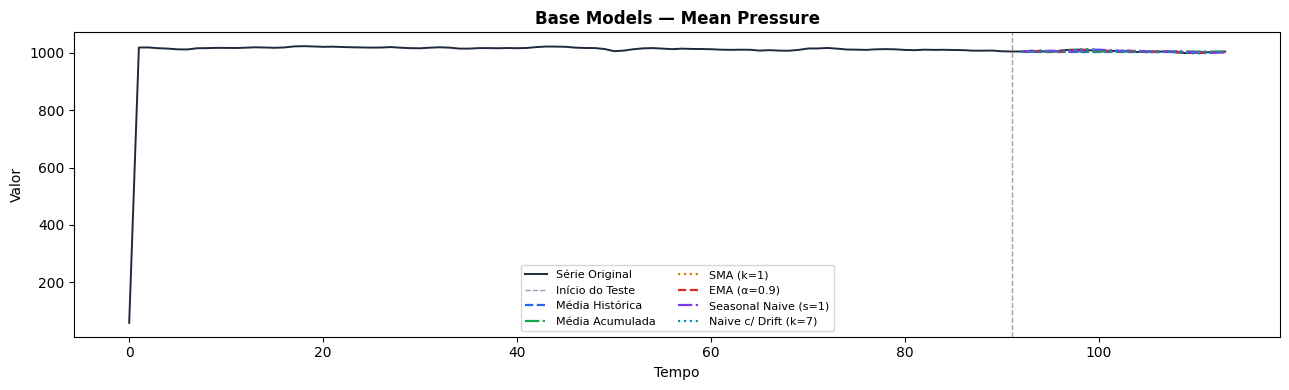


───────────────────────────────────────────────────────
  Treinando modelo SARIMA...
───────────────────────────────────────────────────────


NotImplementedError: Implementar treinar_sarima()

In [26]:
resultados_gerais = {}

for arquivo in ARQUIVOS:
    resultados_gerais[arquivo['nome']] = pipeline_sarima(arquivo)